# AI-Powered HVAC Fault Diagnosis Assistant

Train an XGBoost classifier to identify eight electrical fault classes, then combine its predictions with a retrieval-augmented Mistral assistant for grounded explanations and follow-up questions.

# 1. Environment Setup

Import the Python libraries used for analysis, modelling, evaluation, and visualization.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
from sklearn.metrics import classification_report
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

# 2. Data Loading and Initial Inspection

Download the public Kaggle dataset with KaggleHub, load it into a pandas DataFrame, and inspect its structure.

In [2]:
# Install the KaggleHub pandas adapter when needed.
%pip install -q "kagglehub[pandas-datasets]"

import kagglehub
from kagglehub import KaggleDatasetAdapter


/content/drive/MyDrive/Colab Notebooks/modified_labels.csv


In [3]:
# Download and load the public Kaggle dataset as a pandas DataFrame.
DATASET_HANDLE = "pjay01/solar-panel-fault-detection"
DATASET_FILE = "modified_labels.csv"

ark = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    DATASET_HANDLE,
    DATASET_FILE,
)

print("Dataset loaded:", DATASET_FILE)
print("Shape:", ark.shape)
ark.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
df = ark.copy()

In [5]:
df

,Time,Ipv,Vpv,Vdc,ia,ib,ic,va,vb,vc,Iabc,If,Vabc,Vf,Label
0,0.000098,1.975342,86.627197,145.312500,0.146850,0.322266,-0.509404,-50.375519,-98.906708,156.137187,1.000000,50.000000,1.000000,50.000000,F4
1,0.000198,2.078461,86.499023,145.605469,0.119994,0.328979,-0.509404,-45.891266,-99.955444,154.453583,1.000000,50.000000,1.000000,50.000000,F4
2,0.000298,1.989532,87.774658,145.312500,0.140136,0.369263,-0.469121,-43.552704,-103.812866,151.990458,1.000000,50.000000,1.000000,50.000000,F4
3,0.000398,1.823975,87.756348,145.312500,0.106566,0.375977,-0.482549,-38.140259,-109.442291,151.411845,1.000000,50.000000,1.000000,50.000000,F4
4,0.000498,1.777618,87.896729,145.019531,0.099853,0.375977,-0.475835,-33.523407,-112.492065,149.905039,1.000000,50.000000,1.000000,50.000000,F4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2163475,14.399588,1.440826,101.574707,142.675781,0.469115,-0.537109,0.061274,-129.862518,139.530182,-9.430593,0.525074,49.937214,155.541659,50.004734,F7
2163476,14.399688,1.496643,101.916504,142.675781,0.422118,-0.463257,0.027705,-133.177490,137.878723,-6.416982,0.525074,49.937214,155.541659,50.004734,F7
2163477,14.399788,1.484344,102.484131,142.968750,0.475829,-0.523682,0.027705,-135.576324,134.346771,0.755412,0.524933,49.944112,155.545206,50.004216,F7
2163478,14.399888,1.507996,101.788330,142.968750,0.448974,-0.429688,0.000850,-137.818451,132.273407,6.023204,0.524933,49.944112,155.545206,50.004216,F7


In [41]:
df.columns

Index(['Time', 'Ipv', 'Vpv', 'Vdc', 'ia', 'ib', 'ic', 'va', 'vb', 'vc', 'Iabc',
       'If', 'Vabc', 'Vf', 'Label'],
      dtype='object')

# 3. Exploratory Data Analysis

Explore distributions, descriptive statistics, correlations, and electrical relationships in the dataset.

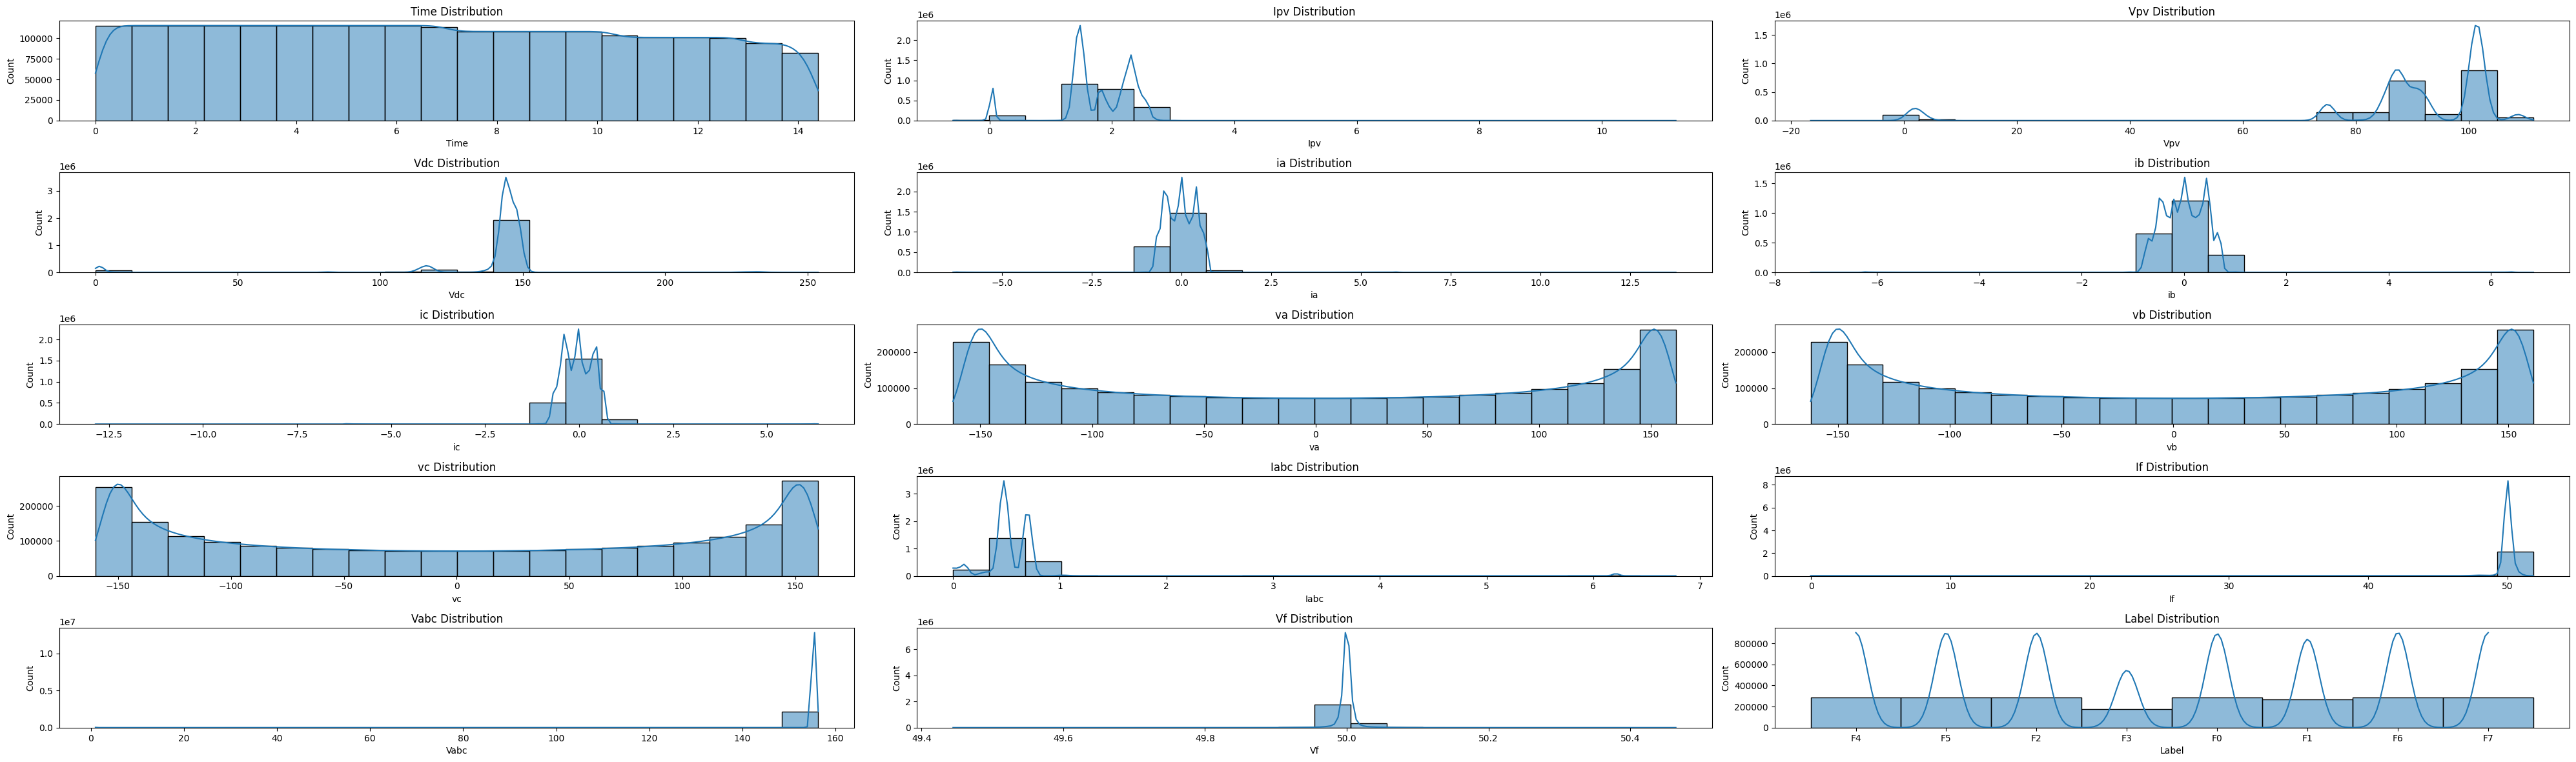

In [42]:


# List of columns
cols = ['Time', 'Ipv', 'Vpv', 'Vdc', 'ia', 'ib', 'ic', 'va', 'vb', 'vc', 'Iabc',
       'If', 'Vabc', 'Vf', 'Label']

# Set figure size
plt.figure(figsize=(40, 35))

# Loop through columns
for i, col in enumerate(cols, 1):

    plt.subplot(15, 3, i) #[rows, columns, position]

    sns.histplot(
        ark[col],
        kde=True,
        bins=20
    )

    plt.title(f"{col} Distribution")

# Adjust spacing
plt.tight_layout()

# Show plots
plt.show()

In [43]:
  # check if constant
print(df.describe())                     # min, max, mean of every column

               Time           Ipv           Vpv           Vdc            ia  \
count  2.163480e+06  2.163480e+06  2.163480e+06  2.163480e+06  2.163480e+06   
mean   6.901942e+00  1.777343e+00  8.810269e+01  1.393910e+02 -2.103150e-02   
std    4.082440e+00  6.033849e-01  2.324239e+01  2.733158e+01  5.720828e-01   
min    3.900159e-06 -5.950623e-01 -1.655884e+01  0.000000e+00 -6.358888e+00   
25%    3.379926e+00  1.463531e+00  8.700562e+01  1.432617e+02 -3.835459e-01   
50%    6.759857e+00  1.791809e+00  9.131470e+01  1.444336e+02 -1.428320e-02   
75%    1.034940e+01  2.283752e+00  1.013977e+02  1.473633e+02  3.415518e-01   
max    1.440000e+01  1.120874e+01  1.114746e+02  2.537109e+02  1.376929e+01   

                 ib            ic            va            vb            vc  \
count  2.163480e+06  2.163480e+06  2.163480e+06  2.163480e+06  2.163480e+06   
mean   1.563835e-03 -2.372308e-02  8.390207e-01  8.219660e-01  8.256761e-01   
std    5.757026e-01  5.637509e-01  1.098731e+02  1.

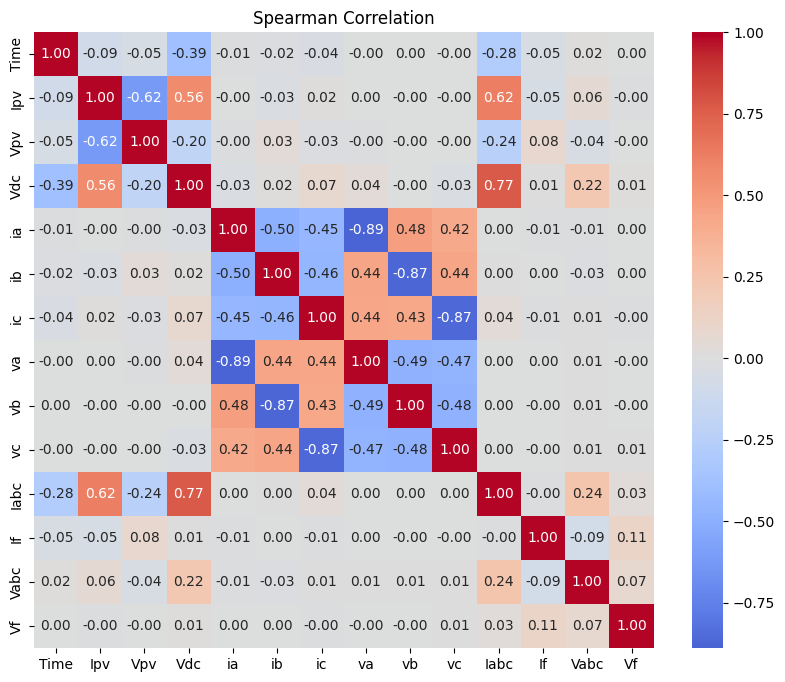

In [44]:
spearman_corr = df.drop(columns=['Label']).corr(method='spearman')

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title("Spearman Correlation")
plt.show()

In [45]:
import numpy as np
print(df[['Iabc', 'ia', 'ib', 'ic']].describe())
df['i_rms_check'] = np.sqrt((df['ia']**2 + df['ib']**2 + df['ic']**2)/3)
print(df[['Iabc', 'i_rms_check']].corr())

               Iabc            ia            ib            ic
count  2.163480e+06  2.163480e+06  2.163480e+06  2.163480e+06
mean   5.649684e-01 -2.103150e-02  1.563835e-03 -2.372308e-02
std    5.577446e-01  5.720828e-01  5.757026e-01  5.637509e-01
min    5.942768e-09 -6.358888e+00 -7.297974e+00 -1.285621e+01
25%    4.552899e-01 -3.835459e-01 -3.356934e-01 -3.482715e-01
50%    4.943000e-01 -1.428320e-02  6.713867e-03 -3.271973e-02
75%    6.799564e-01  3.415518e-01  3.558350e-01  3.231152e-01
max    6.774100e+00  1.376929e+01  6.828003e+00  6.358882e+00
                 Iabc  i_rms_check
Iabc         1.000000     0.981809
i_rms_check  0.981809     1.000000


In [46]:
import numpy as np

# Step 1: create v_rms
df['v_rms'] = np.sqrt((df['va']**2 + df['vb']**2 + df['vc']**2) / 3)

# Step 2: check redundancy against Vabc
correlation = df[['Vabc', 'v_rms']].corr()
print(correlation)

          Vabc    v_rms
Vabc   1.00000  0.02765
v_rms  0.02765  1.00000


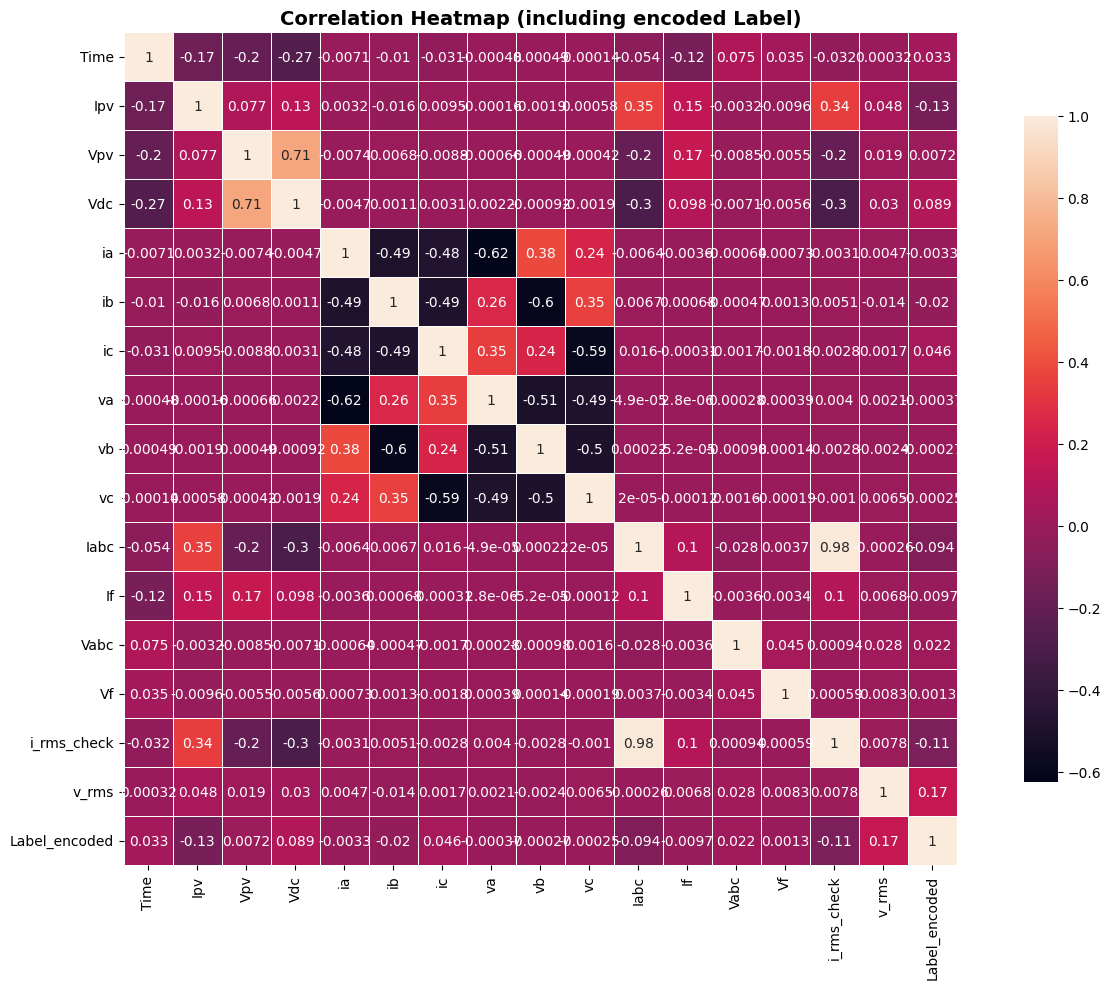

In [47]:
from sklearn.preprocessing import LabelEncoder
# Step 1: Encode Label into numbers so corr() can use it
le = LabelEncoder()
df['Label_encoded'] = le.fit_transform(df['Label'])   # F0->0, F1->1, F2->2, etc.

# Step 2: Calculate correlation INCLUDING the encoded label
correlation_matrix = df.drop(columns=['Label']).corr()   # drop original text column, keep Label_encoded

# Step 3: Plot the heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Heatmap (including encoded Label)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 4. Data Preparation

Check data quality, inspect target classes, and prepare the working DataFrame for feature engineering.

In [6]:
df.isnull().sum()

,0
Time,0
Ipv,0
Vpv,0
Vdc,0
ia,0
ib,0
ic,0
va,0
vb,0
vc,0


In [7]:
df['Label'].unique()

array(['F4', 'F5', 'F2', 'F3', 'F0', 'F1', 'F6', 'F7'], dtype=object)

In [8]:
#df.drop('Time', axis=1, inplace=True)
#df.drop('Label_encoded', axis=1, inplace=True)




# 5. Feature Engineering

Create electrical features that help the model distinguish normal operation from fault conditions.

In [9]:
import numpy as np
df['v_rms'] = np.sqrt((df['va']**2 + df['vb']**2 + df['vc']**2) / 3)


In [10]:
import numpy as np

# --- PV-side power ---
df['Ppv'] = df['Ipv'] * df['Vpv']

# --- Impedance-like features (with epsilon to avoid divide-by-zero) ---
epsilon = 1e-6
df['Xa'] = df['va'] / (df['ia'] + epsilon)
df['Xb'] = df['vb'] / (df['ib'] + epsilon)
df['Xc'] = df['vc'] / (df['ic'] + epsilon)
df['Xf'] = df['Vf'] / (df['If'] + epsilon)


In [11]:
import numpy as np
import pandas as pd

# =========================================
# VALUE OF a
# =========================================

a = complex(-0.5, np.sqrt(3)/2)

a2 = complex(-0.5, -np.sqrt(3)/2)

# =========================================
# FUNCTION TO CALCULATE
# X0 X1 X2
# =========================================

def symmetrical_components(xa, xb, xc):

    X0 = (xa + xb + xc) / 3

    X1 = (xa + a*xb + a2*xc) / 3

    X2 = (xa + a2*xb + a*xc) / 3

    return X0, X1, X2

# =========================================
# SAVE X0 X1 X2 INTO DATAFRAME
# =========================================

df[['X0', 'X1', 'X2']] = df.apply(
    lambda row: symmetrical_components(
        row['Xa'],
        row['Xb'],
        row['Xc']
    ),
    axis=1,
    result_type='expand'
)

# =========================================
# MODULUS (MAGNITUDE) OF X0 X1 X2
# =========================================

df['X0'] = df['X0'].apply(np.abs)
df['X1'] = df['X1'].apply(np.abs)
df['X2'] = df['X2'].apply(np.abs)

In [12]:
df

,Time,Ipv,Vpv,Vdc,ia,ib,ic,va,vb,vc,...,Label,v_rms,Ppv,Xa,Xb,Xc,Xf,X0,X1,X2
0,0.000098,1.975342,86.627197,145.312500,0.146850,0.322266,-0.509404,-50.375519,-98.906708,156.137187,...,F4,110.602970,171.118324,-343.039222,-306.909559,-306.509965,1.000000,318.819582,12.110369,12.110369
1,0.000198,2.078461,86.499023,145.605469,0.119994,0.328979,-0.509404,-45.891266,-99.955444,154.453583,...,F4,109.472993,179.784820,-382.442703,-303.833956,-303.204914,1.000000,329.827191,26.308383,26.308383
2,0.000298,1.989532,87.774658,145.312500,0.140136,0.369263,-0.469121,-43.552704,-103.812866,151.990458,...,F4,109.201722,174.630533,-310.787187,-281.134776,-323.990509,1.000000,305.304157,12.671506,12.671506
3,0.000398,1.823975,87.756348,145.312500,0.106566,0.375977,-0.482549,-38.140259,-109.442291,151.411845,...,F4,110.087603,160.065350,-357.897974,-291.087294,-313.775829,1.000000,320.920366,19.614621,19.614621
4,0.000498,1.777618,87.896729,145.019531,0.099853,0.375977,-0.475835,-33.523407,-112.492065,149.905039,...,F4,109.923920,156.246843,-335.725777,-299.198880,-315.036445,1.000000,316.653700,10.575368,10.575368
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2163475,14.399588,1.440826,101.574707,142.675781,0.469115,-0.537109,0.061274,-129.862518,139.530182,-9.430593,...,F7,110.184514,146.351521,-276.823757,-259.780313,-153.905004,1.001352,230.169691,38.448436,38.448436
2163476,14.399688,1.496643,101.916504,142.675781,0.422118,-0.463257,0.027705,-133.177490,137.878723,-6.416982,...,F7,110.736871,152.532629,-315.497380,-297.629760,-231.609179,1.001352,281.578773,25.511652,25.511652
2163477,14.399788,1.484344,102.484131,142.968750,0.475829,-0.523682,0.027705,-135.576324,134.346771,0.755412,...,F7,110.197649,152.121754,-284.925910,-256.543322,27.265201,1.001203,171.401344,99.670607,99.670607
2163478,14.399888,1.507996,101.788330,142.968750,0.448974,-0.429688,0.000850,-137.818451,132.273407,6.023204,...,F7,110.342586,153.496354,-306.962667,-307.837009,7081.045318,1.001203,2155.415214,2462.815065,2462.815065


In [13]:
df.columns

Index(['Time', 'Ipv', 'Vpv', 'Vdc', 'ia', 'ib', 'ic', 'va', 'vb', 'vc', 'Iabc',
       'If', 'Vabc', 'Vf', 'Label', 'v_rms', 'Ppv', 'Xa', 'Xb', 'Xc', 'Xf',
       'X0', 'X1', 'X2'],
      dtype='object')

# 6. Categorical Encoding and Feature Scaling

Convert categorical values into numeric features and scale the model inputs.

In [14]:
# =========================================================
# ONE HOT ENCODING
# =========================================================

# Create copy similar to df_encoded
df_encoded = df.copy()

# Apply One Hot Encoding on Label column
df_encoded = pd.get_dummies(
    df_encoded,
    columns=['Label']
)

# Display dataframe
df_encoded

,Time,Ipv,Vpv,Vdc,ia,ib,ic,va,vb,vc,...,X1,X2,Label_F0,Label_F1,Label_F2,Label_F3,Label_F4,Label_F5,Label_F6,Label_F7
0,0.000098,1.975342,86.627197,145.312500,0.146850,0.322266,-0.509404,-50.375519,-98.906708,156.137187,...,12.110369,12.110369,False,False,False,False,True,False,False,False
1,0.000198,2.078461,86.499023,145.605469,0.119994,0.328979,-0.509404,-45.891266,-99.955444,154.453583,...,26.308383,26.308383,False,False,False,False,True,False,False,False
2,0.000298,1.989532,87.774658,145.312500,0.140136,0.369263,-0.469121,-43.552704,-103.812866,151.990458,...,12.671506,12.671506,False,False,False,False,True,False,False,False
3,0.000398,1.823975,87.756348,145.312500,0.106566,0.375977,-0.482549,-38.140259,-109.442291,151.411845,...,19.614621,19.614621,False,False,False,False,True,False,False,False
4,0.000498,1.777618,87.896729,145.019531,0.099853,0.375977,-0.475835,-33.523407,-112.492065,149.905039,...,10.575368,10.575368,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2163475,14.399588,1.440826,101.574707,142.675781,0.469115,-0.537109,0.061274,-129.862518,139.530182,-9.430593,...,38.448436,38.448436,False,False,False,False,False,False,False,True
2163476,14.399688,1.496643,101.916504,142.675781,0.422118,-0.463257,0.027705,-133.177490,137.878723,-6.416982,...,25.511652,25.511652,False,False,False,False,False,False,False,True
2163477,14.399788,1.484344,102.484131,142.968750,0.475829,-0.523682,0.027705,-135.576324,134.346771,0.755412,...,99.670607,99.670607,False,False,False,False,False,False,False,True
2163478,14.399888,1.507996,101.788330,142.968750,0.448974,-0.429688,0.000850,-137.818451,132.273407,6.023204,...,2462.815065,2462.815065,False,False,False,False,False,False,False,True


In [15]:
df_encoded.columns

Index(['Time', 'Ipv', 'Vpv', 'Vdc', 'ia', 'ib', 'ic', 'va', 'vb', 'vc', 'Iabc',
       'If', 'Vabc', 'Vf', 'v_rms', 'Ppv', 'Xa', 'Xb', 'Xc', 'Xf', 'X0', 'X1',
       'X2', 'Label_F0', 'Label_F1', 'Label_F2', 'Label_F3', 'Label_F4',
       'Label_F5', 'Label_F6', 'Label_F7'],
      dtype='object')

In [16]:
df_encoded= df_encoded.astype(int)
df_encoded

,Time,Ipv,Vpv,Vdc,ia,ib,ic,va,vb,vc,...,X1,X2,Label_F0,Label_F1,Label_F2,Label_F3,Label_F4,Label_F5,Label_F6,Label_F7
0,0,1,86,145,0,0,0,-50,-98,156,...,12,12,0,0,0,0,1,0,0,0
1,0,2,86,145,0,0,0,-45,-99,154,...,26,26,0,0,0,0,1,0,0,0
2,0,1,87,145,0,0,0,-43,-103,151,...,12,12,0,0,0,0,1,0,0,0
3,0,1,87,145,0,0,0,-38,-109,151,...,19,19,0,0,0,0,1,0,0,0
4,0,1,87,145,0,0,0,-33,-112,149,...,10,10,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2163475,14,1,101,142,0,0,0,-129,139,-9,...,38,38,0,0,0,0,0,0,0,1
2163476,14,1,101,142,0,0,0,-133,137,-6,...,25,25,0,0,0,0,0,0,0,1
2163477,14,1,102,142,0,0,0,-135,134,0,...,99,99,0,0,0,0,0,0,0,1
2163478,14,1,101,142,0,0,0,-137,132,6,...,2462,2462,0,0,0,0,0,0,0,1


In [17]:
# =========================================================
# STANDARD SCALING
# =========================================================

from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Copy dataframe
df_scaled = df_encoded.copy()

# Select feature columns
feature_columns = df_scaled.drop(
    columns=[
        'Label_F0',
        'Label_F1',
        'Label_F2',
        'Label_F3',
        'Label_F4',
        'Label_F5',
        'Label_F6',
        'Label_F7'
    ]
).columns

# Scale features
df_scaled[feature_columns] = scaler.fit_transform(
    df_scaled[feature_columns]
)

# Display dataframe
df_scaled

,Time,Ipv,Vpv,Vdc,ia,ib,ic,va,vb,vc,...,X1,X2,Label_F0,Label_F1,Label_F2,Label_F3,Label_F4,Label_F5,Label_F6,Label_F7
0,-1.569090,-0.583732,-0.068932,0.223453,0.001345,-0.000573,0.000745,-0.464591,-0.903082,1.418276,...,-0.077904,-0.077904,0,0,0,0,1,0,0,0
1,-1.569090,1.098047,-0.068932,0.223453,0.001345,-0.000573,0.000745,-0.418897,-0.912220,1.399996,...,-0.077899,-0.077899,0,0,0,0,1,0,0,0
2,-1.569090,-0.583732,-0.025900,0.223453,0.001345,-0.000573,0.000745,-0.400619,-0.948775,1.372577,...,-0.077904,-0.077904,0,0,0,0,1,0,0,0
3,-1.569090,-0.583732,-0.025900,0.223453,0.001345,-0.000573,0.000745,-0.354925,-1.003606,1.372577,...,-0.077902,-0.077902,0,0,0,0,1,0,0,0
4,-1.569090,-0.583732,-0.025900,0.223453,0.001345,-0.000573,0.000745,-0.309231,-1.031022,1.354297,...,-0.077905,-0.077905,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2163475,1.858508,-0.583732,0.576537,0.113546,0.001345,-0.000573,0.000745,-1.186555,1.262773,-0.089789,...,-0.077895,-0.077895,0,0,0,0,0,0,0,1
2163476,1.858508,-0.583732,0.576537,0.113546,0.001345,-0.000573,0.000745,-1.223110,1.244496,-0.062370,...,-0.077900,-0.077900,0,0,0,0,0,0,0,1
2163477,1.858508,-0.583732,0.619568,0.113546,0.001345,-0.000573,0.000745,-1.241387,1.217080,-0.007531,...,-0.077874,-0.077874,0,0,0,0,0,0,0,1
2163478,1.858508,-0.583732,0.576537,0.113546,0.001345,-0.000573,0.000745,-1.259665,1.198803,0.047308,...,-0.077062,-0.077062,0,0,0,0,0,0,0,1


In [18]:
df_scaled.columns

Index(['Time', 'Ipv', 'Vpv', 'Vdc', 'ia', 'ib', 'ic', 'va', 'vb', 'vc', 'Iabc',
       'If', 'Vabc', 'Vf', 'v_rms', 'Ppv', 'Xa', 'Xb', 'Xc', 'Xf', 'X0', 'X1',
       'X2', 'Label_F0', 'Label_F1', 'Label_F2', 'Label_F3', 'Label_F4',
       'Label_F5', 'Label_F6', 'Label_F7'],
      dtype='object')

# 7. Feature Selection and Dataset Split

Separate the input features from the target label and prepare training and testing data.

In [19]:
# =========================================================
# FEATURES (X) AND TARGET (y)
# =========================================================

# Features
X = df_scaled.drop(columns=[
    'Label_F0',
    'Label_F1',
    'Label_F2',
    'Label_F3',
    'Label_F4',
    'Label_F5',
    'Label_F6',
    'Label_F7'
])

# Target
y = df_scaled[[
    'Label_F0',
    'Label_F1',
    'Label_F2',
    'Label_F3',
    'Label_F4',
    'Label_F5',
    'Label_F6',
    'Label_F7'
]].idxmax(axis=1)

# Convert 'Label_F0'...'Label_F7' -> 0...7
y = y.str.replace('Label_F', '', regex=False).astype(int)

# =========================================================
# TRAIN TEST SPLIT
# =========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size :", X_train.shape[0])
print("Test size  :", X_test.shape[0])

Train size : 1730784
Test size  : 432696


# 8. XGBoost Model Training

Train the multiclass fault-detection model using the prepared HVAC features.

In [20]:


# =========================================================
# ADVANCED XGBOOST CLASSIFIER
# =========================================================

from xgboost import XGBClassifier

# =========================================================
# CREATE MODEL
# =========================================================

model = XGBClassifier(

    # =====================================================
    # BASIC SETTINGS
    # =====================================================
    objective='multi:softmax',
    num_class=len(set(y)),
    random_state=42,
    eval_metric='mlogloss',

    # =====================================================
    # BOOSTING PARAMETERS
    # =====================================================
    n_estimators=200,
    learning_rate=0.03,
    max_depth=5,
    min_child_weight=2,
    gamma=0.2,

    # =====================================================
    # SAMPLING
    # =====================================================
    subsample=0.8,
    colsample_bytree=0.8,

    # =====================================================
    # REGULARIZATION
    # =====================================================
    reg_alpha=0.1,
    reg_lambda=1,

    # =====================================================
    # PERFORMANCE
    # =====================================================
    n_jobs=-1,
    tree_method='hist'
)

# =========================================================
# TRAIN MODEL
# =========================================================

model.fit(
    X_train,
    y_train
)

print("Model Trained Successfully")



Model Trained Successfully


# 9. Model Evaluation

Generate predictions and evaluate the trained classifier on unseen test data.

In [21]:
# =========================================================
# PREDICTIONS
# =========================================================

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# =========================================================
# ACCURACY
# =========================================================

from sklearn.metrics import accuracy_score

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("\nTrain Accuracy :", train_accuracy)
print("Test Accuracy  :", test_accuracy)

# =========================================================
# CONFUSION MATRIX
# =========================================================

from sklearn.metrics import confusion_matrix

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_test_pred))

# =========================================================
# CLASSIFICATION REPORT
# =========================================================

from sklearn.metrics import classification_report

print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred))

# =========================================================
# SAVE MODEL
# =========================================================

import joblib

joblib.dump(model, "xgboost_fault_model.pkl")

print("\nModel Saved Successfully")


Train Accuracy : 0.8041506045815076
Test Accuracy  : 0.8030395473958623

Confusion Matrix:

[[49193   398   840  2833     0   412   977  2293]
 [ 1545 42820   898   889     8   958  2135  4352]
 [ 3397  2939 43534   777     2   632  2978  2970]
 [ 6134  2844  1351 15293     0  1177  3826  4068]
 [    0     0     0     0 57593     5     0     7]
 [ 2756   948  1310   817     4 42759  2899  5913]
 [  870   384   320   423     0    29 52153  3427]
 [ 3054  1484   675   209    17  1467  6573 44127]]

Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.86      0.79     56946
           1       0.83      0.80      0.81     53605
           2       0.89      0.76      0.82     57229
           3       0.72      0.44      0.55     34693
           4       1.00      1.00      1.00     57605
           5       0.90      0.74      0.82     57406
           6       0.73      0.91      0.81     57606
           7       0.66      0.77      0

# 10. Dataset and Leakage Validation

Check the final feature set and confirm that the training and testing samples remain separated.

In [ ]:
print(X.columns.tolist())
print(X_train.shape, X_test.shape)
print(len(set(map(tuple, X_train.values)) & set(map(tuple, X_test.values))))  # overlapping rows

# 11. RAG Dependencies and API Configuration

Install the retrieval dependencies and configure secure access to the language model.

In [ ]:

!pip install -q -U langchain-community langchain-text-splitters langchain-chroma chromadb sentence-transformers pypdf groq

In [ ]:
pip install -qU langchain-mistralai


In [ ]:
import os, getpass

# force re-entry even if a stale key exists
os.environ.pop("MISTRAL_API_KEY", None)
os.environ["MISTRAL_API_KEY"] = getpass.getpass("Enter your Mistral API key: ")

In [ ]:
pip install -U langchain-opendataloader-pdf

# 12. RAG and Machine-Learning Assistant

Combine model predictions with retrieved technical context to produce fault explanations.

In [ ]:

# =========================================================
# COMPLETE RAG + ML CHATBOT SYSTEM
# =========================================================

# =========================================================
# IMPORTS
# =========================================================

import pandas as pd
import joblib
import ipywidgets as widgets

from IPython.display import display

from langchain_community.document_loaders import (
    PyPDFLoader
)

from langchain_text_splitters import (
    RecursiveCharacterTextSplitter
)

from langchain_community.embeddings import (
    HuggingFaceEmbeddings
)

from langchain_chroma import Chroma

from langchain_mistralai import ChatMistralAI

# =========================================================
# LOAD ML MODEL
# =========================================================

model = joblib.load(
    "xgboost_fault_model.pkl"
)

# =========================================================
# FAULT LABELS
# =========================================================

fault_labels = {
    0: "Label_F0",
    1: "Label_F1",
    2: "Label_F2",
    3: "Label_F3",
    4: "Label_F4",
    5: "Label_F5",
    6: "Label_F6",
    7: "Label_F7"
}

# =========================================================
# LOAD PDF DOCUMENT
# =========================================================

loader = PyPDFLoader(
    "Three_Phase_Power_System_Fault_Reference.pdf"
)

documents = loader.load()

print("PDF Loaded Successfully")
print("Pages :", len(documents))

# =========================================================
# SPLIT DOCUMENTS
# =========================================================

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1200,
    chunk_overlap=250
)

docs = text_splitter.split_documents(
    documents
)

print("Chunks Created :", len(docs))

# =========================================================
# EMBEDDING MODEL
# =========================================================

embedding_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

# =========================================================
# VECTOR DATABASE
# =========================================================

vectorstore = Chroma.from_documents(
    documents=docs,
    embedding=embedding_model,
    persist_directory="chroma_db"
)

# =========================================================
# RETRIEVER
# =========================================================

retriever = vectorstore.as_retriever(
    search_kwargs={"k": 5}
)

# =========================================================
# MISTRAL CLIENT
# =========================================================

client = ChatMistralAI(
    model="mistral-large-latest",
    temperature=0.2,
    max_retries=2
)

# =========================================================
# MEMORY STORAGE
# =========================================================

chat_history = []

last_fault = {
    "label": None,
    "values": None
}

# =========================================================
# RAG FUNCTION
# =========================================================

def ask_ai(question):

    retrieved_docs = retriever.invoke(
        question
    )

    context = "\n\n".join([
        doc.page_content
        for doc in retrieved_docs
    ])

    history_text = "\n".join(chat_history[-6:])

    prompt = f"""
You are an Electrical Power System Fault
Diagnosis AI Assistant.

You must:
- Explain faults clearly
- Explain causes
- Explain prevention
- Explain troubleshooting
- Explain voltage/current behavior
- Answer ONLY from provided context
- Be technical but easy to understand

Chat History:
{history_text}

Context:
{context}

Question:
{question}
"""

    response = client.invoke(prompt)

    answer = response.content

    chat_history.append(
        f"User: {question}"
    )

    chat_history.append(
        f"Assistant: {answer}"
    )

    return answer

# =========================================================
# INPUT WIDGETS
# =========================================================

Ipv = widgets.FloatText(
    description='Ipv',
    value=0
)

Vpv = widgets.FloatText(
    description='Vpv',
    value=0
)

Vdc = widgets.FloatText(
    description='Vdc',
    value=0
)

ia = widgets.FloatText(
    description='ia',
    value=0
)

ib = widgets.FloatText(
    description='ib',
    value=0
)

ic = widgets.FloatText(
    description='ic',
    value=0
)

va = widgets.FloatText(
    description='va',
    value=0
)

vb = widgets.FloatText(
    description='vb',
    value=0
)

vc = widgets.FloatText(
    description='vc',
    value=0
)

Iabc = widgets.FloatText(
    description='Iabc',
    value=0
)

Ifault = widgets.FloatText(
    description='If',
    value=0
)

Vabc = widgets.FloatText(
    description='Vabc',
    value=0
)

Vf = widgets.FloatText(
    description='Vf',
    value=0
)

# =========================================================
# SYMMETRICAL COMPONENT WIDGETS
# =========================================================

Xa = widgets.FloatText(
    description='Xa',
    value=0
)

Xb = widgets.FloatText(
    description='Xb',
    value=0
)

Xc = widgets.FloatText(
    description='Xc',
    value=0
)

Xf = widgets.FloatText(
    description='Xf',
    value=0
)

X0 = widgets.FloatText(
    description='X0',
    value=0
)

X1 = widgets.FloatText(
    description='X1',
    value=0
)

X2 = widgets.FloatText(
    description='X2',
    value=0
)

# =========================================================
# CHAT WIDGETS
# =========================================================

predict_button = widgets.Button(
    description='Predict Fault'
)

chat_box = widgets.Text(
    placeholder='Ask anything about the fault...'
)

send_button = widgets.Button(
    description='Send'
)

clear_button = widgets.Button(
    description='Clear Chat'
)

output = widgets.Output()

# =========================================================
# PREDICT FUNCTION
# =========================================================

def predict_fault(button):

    with output:

        output.clear_output()

        # =====================================================
        # CREATE INPUT DATA
        # =====================================================

        input_data = pd.DataFrame([[

            Ipv.value,
            Vpv.value,
            Vdc.value,

            ia.value,
            ib.value,
            ic.value,

            va.value,
            vb.value,
            vc.value,

            Iabc.value,
            Ifault.value,
            Vabc.value,
            Vf.value,

            Xa.value,
            Xb.value,
            Xc.value,
            Xf.value,
            X0.value,
            X1.value,
            X2.value

        ]], columns=[

            'Ipv',
            'Vpv',
            'Vdc',

            'ia',
            'ib',
            'ic',

            'va',
            'vb',
            'vc',

            'Iabc',
            'If',
            'Vabc',
            'Vf',

            'Xa',
            'Xb',
            'Xc',
            'Xf',
            'X0',
            'X1',
            'X2'
        ])

        # =====================================================
        # ML PREDICTION
        # =====================================================

        prediction = model.predict(
            input_data
        )[0]

        predicted_label = fault_labels[
            prediction
        ]

        # =====================================================
        # STORE MEMORY
        # =====================================================

        last_fault["label"] = predicted_label

        last_fault["values"] = input_data

        # =====================================================
        # DISPLAY RESULT
        # =====================================================

        print("=" * 60)

        print("ML FAULT PREDICTION")

        print("=" * 60)

        print(
            f"\nPredicted Fault : {predicted_label}"
        )

        print("\nSensor Values:\n")

        print(input_data)

        # =====================================================
        # AI EXPLANATION
        # =====================================================

        print("\nGenerating AI Explanation...\n")

        explanation = ask_ai(
            f"""
Explain electrical fault
{predicted_label}.

Sensor values:
{input_data.to_string(index=False)}

Include:
- fault meaning
- likely causes
- voltage behavior
- current behavior
- dangerous conditions
- troubleshooting
- protection methods
- prevention methods
"""
        )

        print(explanation)

# =========================================================
# CHAT FUNCTION
# =========================================================

def send_message(button):

    with output:

        question = chat_box.value

        if not question.strip():

            return

        print("\n" + "=" * 60)

        print("USER QUESTION")

        print("=" * 60)

        print(question)

        # =====================================================
        # ADD CURRENT FAULT CONTEXT
        # =====================================================

        if last_fault["label"] is not None:

            enhanced_question = f"""
Current Fault:
{last_fault['label']}

Question:
{question}
"""

        else:

            enhanced_question = question

        # =====================================================
        # GET AI RESPONSE
        # =====================================================

        answer = ask_ai(
            enhanced_question
        )

        print("\n" + "=" * 60)

        print("AI RESPONSE")

        print("=" * 60)

        print(answer)

        chat_box.value = ""

# =========================================================
# CLEAR CHAT
# =========================================================

def clear_chat(button):

    with output:

        output.clear_output()

    chat_history.clear()

    last_fault["label"] = None

    last_fault["values"] = None

    print("Chat Cleared")

# =========================================================
# BUTTON EVENTS
# =========================================================

predict_button.on_click(
    predict_fault
)

send_button.on_click(
    send_message
)

clear_button.on_click(
    clear_chat
)

# =========================================================
# DISPLAY INTERFACE
# =========================================================

title = widgets.HTML(
    "<h2>Electrical Fault Diagnosis RAG Chatbot</h2>"
)

display(title)

display(
    Ipv,
    Vpv,
    Vdc,

    ia,
    ib,
    ic,

    va,
    vb,
    vc,

    Iabc,
    Ifault,
    Vabc,
    Vf,

    Xa,
    Xb,
    Xc,
    Xf,
    X0,
    X1,
    X2
)

display(
    widgets.HBox([
        predict_button,
        clear_button
    ])
)

display(output)

display(
    widgets.HBox([
        chat_box,
        send_button
    ])
)
```


# 13. Fault Label Reference

Use this table to interpret the predicted HVAC fault class.

# | Fault Label | Fault Type                        | Description                                   |
| ----------- | --------------------------------- | --------------------------------------------- |
| `F0`        | Normal Condition                  | System working normally                       |
| `F1`        | Line to Ground Fault (LG)         | One phase touches ground                      |
| `F2`        | Line to Line Fault (LL)           | Two phases short together                     |
| `F3`        | Double Line to Ground Fault (LLG) | Two phases connected to ground                |
| `F4`        | Three Phase Fault (LLL)           | All three phases short together               |
| `F5`        | Open Circuit Fault                | Broken wire or loose connection               |
| `F6`        | Short Circuit Fault               | Very low resistance path causing high current |
| `F7`        | Arc Fault                         | Electrical arcing due to damaged/loose wiring |
